<a href="https://colab.research.google.com/github/jolineuichanco/DataAnalytics/blob/main/Week10_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 10**

## **Imbalanced Classes**

In [70]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jcbonilla/BusinessAnalytics/master/BAData/Univ%20Admissions.csv'
df = pd.read_csv(url)

# Remove 'x.' prefix from column names
df.columns = df.columns.str.replace('x.', '', regex=False)
# rename the target column
df = df.rename(columns={'Status.1': 'Status'})

# Create the 'HasApplied' column
df['HasApplied'] = (df['Status'] == 'APPLICANT').astype(int)

df.head()

/tmp/ipykernel_1376/967635745.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Country,State,Gender,Source,GPA,SAT_Score,DistancetoCampus_miles,HouseholdIncome,Status,InState,HasApplied
0,USA,NY,Male,NRCCUA-PurchaseNames,2.0,NaN,44.542651,36990.0,SUSPECT,N,0
1,USA,NY,Male,NRCCUA-PurchaseNames,2.0,NaN,40.501793,33919.0,SUSPECT,N,0
2,USA,NY,Female,NRCCUA-PurchaseNames,2.0,NaN,211.000192,55624.0,SUSPECT,N,0
3,USA,FL,Male,NRCCUA-PurchaseNames,2.0,NaN,1013.992587,33105.0,SUSPECT,N,0
4,USA,NJ,Female,NRCCUA-PurchaseNames,2.0,NaN,59.800086,25999.0,SUSPECT,N,0


<Axes: xlabel='HasApplied', ylabel='count'>

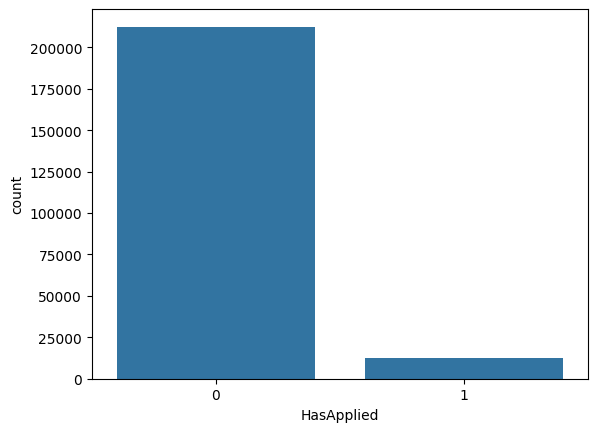

In [68]:
import seaborn as sns

# Create a bar chart of the counts of the 'Status' column
sns.countplot(data=df, x='HasApplied')

### Data cleaning

We will check for `NaN`s, drop columns with a high percentage of missing data, and then impute the rest using the median.

In [86]:
# Define features (X) and target (y) using the 'HasApplied' column
X = df.drop(['Status', 'HasApplied'], axis=1)
y = df['HasApplied']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [88]:
import numpy as np

# Replace any infinite values with NaN before calculating missing percentage
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Calculate missing values percentage for each column in X
missing_percentage = X.isnull().sum() / len(X) * 100

# Drop columns with more than 50% missing values
columns_to_drop = missing_percentage[missing_percentage > 50].index
X = X.drop(columns=columns_to_drop)

# Impute remaining missing numerical values with the median
# Only impute columns that still have NaNs after dropping, and are numerical
for col in X.columns:
    if X[col].isnull().any():
        if pd.api.types.is_numeric_dtype(X[col]):
            median_val = X[col].median()
            X[col] = X[col].fillna(median_val)
        else:
            # For non-numeric types that might still have NaNs (should be rare after one-hot encoding)
            # It's better to drop or fill with a specific placeholder if they exist
            # For now, we'll assume remaining NaNs are in numeric columns.
            # If there are still object/bool columns with NaNs, they will need specific handling.
            X[col] = X[col].fillna(X[col].mode()[0]) # Fill with mode for non-numeric

## Undersampling Imbalanced Classes using `HasApplied`

Let's demonstrate undersampling to balance the classes.

In [89]:
# Display original class distribution
print("Original class distribution of 'HasApplied':")
print(y.value_counts())


Original class distribution of 'HasApplied':
HasApplied
0    212515
1     12500
Name: count, dtype: int64


In [90]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Perform undersampling
X_resampled, y_resampled = rus.fit_resample(X, y)

# Display resampled class distribution
print("\nResampled class distribution of 'HasApplied':")
print(y_resampled.value_counts())


Resampled class distribution of 'HasApplied':
HasApplied
0    12500
1    12500
Name: count, dtype: int64


As you can see from the `value_counts()` output for `y_resampled`, the classes in the `HasApplied` target column are now balanced after applying `RandomUnderSampler`.

## Oversampling Imbalanced Classes using `HasApplied`

Let's demonstrate oversampling to balance the classes using SMOTE.

In [92]:
# Display original class distribution (should be the same as before undersampling)
print("Original class distribution of 'HasApplied':")
print(y.value_counts())

Original class distribution of 'HasApplied':
HasApplied
0    212515
1     12500
Name: count, dtype: int64


In [94]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Perform oversampling on the encoded features
X_resampled_smote, y_resampled_smote = smote.fit_resample(X, y)

# Display resampled class distribution
print("\nResampled class distribution of 'HasApplied' (after SMOTE):")
print(y_resampled_smote.value_counts())



Resampled class distribution of 'HasApplied' (after SMOTE):
HasApplied
0    212515
1    212515
Name: count, dtype: int64


As you can see from the `value_counts()` output for `y_resampled_smote`, the classes in the `HasApplied` target column are now balanced after applying `SMOTE`, with the minority class being increased to match the majority class size.

## **Feature Importance**

Let's use the Titanic dataset again. This is the processed dataset after feature engineering and data cleaning has been done.

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jolineuichanco/DataAnalytics/main/demos/titanic_processed.csv'
df = pd.read_csv(url)

from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state = 42)

In [2]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier()

# Train the model on the training data
dtc.fit(X_train, y_train)

print("Training decision tree successful.")

Training decision tree successful.


### **Impurity-based** feature importance

<Axes: xlabel='importance', ylabel='feature'>

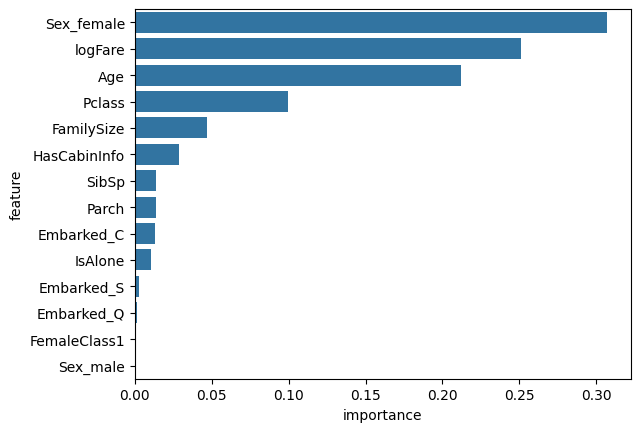

In [3]:
import pandas as pd
import seaborn as sns

# extract the importance of features
importances = dtc.feature_importances_
feature_names = X.columns

# define a dataframe for easy plotting
feature_importance_df = pd.DataFrame({'feature': feature_names,
                                      'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# generate the feature importance plot
sns.barplot(y='feature', x='importance', data=feature_importance_df)

### **Permutation-based** feature importance

<Axes: xlabel='Importance_Mean', ylabel='Feature'>

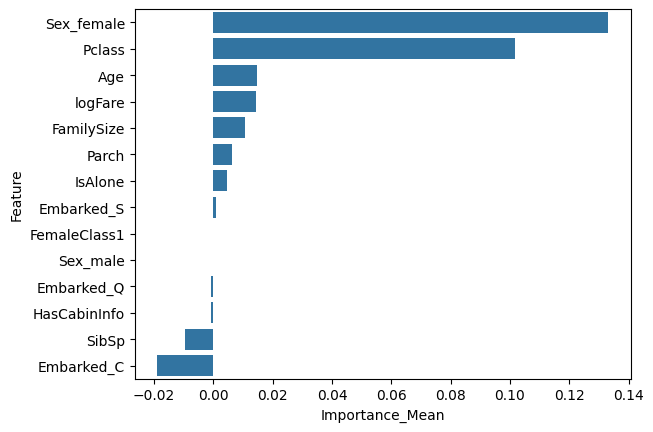

In [4]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate permutation importance
perm_importance = permutation_importance(dtc, X_test, y_test,
                                         n_repeats=10,
                                         random_state = 42)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
})

# Sort the features by mean importance in descending order
perm_importance_df = perm_importance_df.sort_values(by='Importance_Mean', ascending=False)

# Plot the permutation importances
sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df)

## Partial Dependence Plots (PDP)



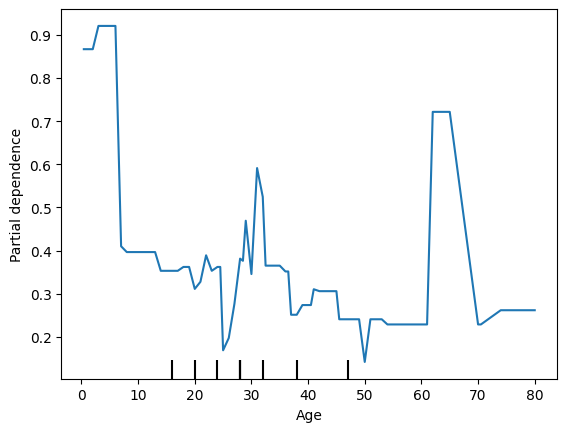

In [5]:
from sklearn.inspection import PartialDependenceDisplay

# Create a partial dependence plot for a single feature (e.g., 'Age')
PartialDependenceDisplay.from_estimator(
    dtc, X_train, ['Age'],
    feature_names=X_train.columns
)

## **Ensemble Methods**

We will discover ensemble learning in today's class. Let us load the SONAR dataset, which is a dataset with many features (60 features), but few number of samples (208 rows). Ensemble models are particularly useful in such datasets.

In [95]:
from sklearn.datasets import fetch_openml

# Load Sonar
sonar = fetch_openml('sonar', version=1, parser='auto', as_frame=True)
X = sonar.data
y = (sonar.target == 'Rock').astype(int)

## Split into Training and Testing sets

In [96]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state = 42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (145, 60)
Shape of X_test: (63, 60)
Shape of y_train: (145,)
Shape of y_test: (63,)


Let us first train a decision tree (without pruning). We will use this as our baseline to see how ensemble improves accuracy.

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state = 42)

# Train the model on the training data
dtc.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of decision tree (without pruning): {accuracy:.4f}")

Accuracy of decision tree (without pruning): 0.7302


## **Ensemble Methods**: Bagging

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Initialize a base estimator (e.g., Decision Tree)
base_estimator = DecisionTreeClassifier()

# Initialize BaggingClassifier
bg_model = BaggingClassifier(estimator=base_estimator,
                             n_estimators=100,
                             max_samples=0.5,
                             oob_score=True,
                             random_state = 42)

# Train the bagging model
bg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bg = bg_model.predict(X_test)

# Evaluate the model
accuracy_bg = accuracy_score(y_test, y_pred_bg)
print(f"Accuracy of bagging classifier: {accuracy_bg:.4f}")
print(f"OOB Accuracy of Bagging Classifier: {bg_model.oob_score_:.4f}")

Accuracy of bagging classifier: 0.7937
OOB Accuracy of Bagging Classifier: 0.7862


Note that by bootstrapping and aggregating ("bagging"), the accuracy is significantly improved even without any pruning.

## **Ensemble Methods:** Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using default parameters for simplicity
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_samples = 0.5,
                                  max_features = "sqrt",
                                  oob_score = True,
                                  random_state = 42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest classifier: {accuracy_rf:.4f}")
print(f"OOB Accuracy of Random Forest Classifier: {rf_model.oob_score_:.4f}")

Accuracy of Random Forest classifier: 0.7778
OOB Accuracy of Random Forest Classifier: 0.8069


Let's how the performance across 30 different experiments (each experiment has a different train/test split).

In [28]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Run experiment with MULTIPLE random seeds
n_experiments = 30
tree_scores = []
bg_scores = []
rf_scores = []

for random_seed in range(n_experiments):
    # Different split each time
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X, y, test_size=0.3, random_state=random_seed, stratify=y
    )

    # Single tree
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train_exp, y_train_exp)
    tree_scores.append(tree.score(X_test_exp, y_test_exp))

    # Bagging
    bg = BaggingClassifier(n_estimators=100,
                           max_samples = 0.5,
                           random_state = 42)
    bg.fit(X_train_exp, y_train_exp)
    bg_scores.append(bg.score(X_test_exp, y_test_exp))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100,
                                max_samples = 0.5,
                                random_state = 42)
    rf.fit(X_train_exp, y_train_exp)
    rf_scores.append(rf.score(X_test_exp, y_test_exp))

# Convert to arrays
tree_scores = np.array(tree_scores)
bg_scores = np.array(bg_scores)
rf_scores = np.array(rf_scores)

# Statistics
print("\n" + "="*70)
print("RESULTS ACROSS 30 DIFFERENT TRAIN/TEST SPLITS:")
print("="*70)

results = pd.DataFrame({
    'Model': ['Single Decision Tree', 'Bagging (100 trees)', 'Random Forest (100 trees)'],
    'Mean Accuracy': [f"{tree_scores.mean():.3f}", f"{bg_scores.mean():.3f}", f"{rf_scores.mean():.3f}"],
    'Std Dev': [f"{tree_scores.std():.3f}", f"{bg_scores.std():.3f}", f"{rf_scores.std():.3f}"],
    'Min': [f"{tree_scores.min():.3f}", f"{bg_scores.min():.3f}", f"{rf_scores.min():.3f}"],
    'Max': [f"{tree_scores.max():.3f}", f"{bg_scores.max():.3f}", f"{rf_scores.max():.3f}"],
    'Range': [f"{tree_scores.max() - tree_scores.min():.3f}",
              f"{bg_scores.max() - bg_scores.min():.3f}",
              f"{rf_scores.max() - rf_scores.min():.3f}"]
})

print("\n" + results.to_string(index=False))



RESULTS ACROSS 30 DIFFERENT TRAIN/TEST SPLITS:

                    Model Mean Accuracy Std Dev   Min   Max Range
     Single Decision Tree         0.712   0.044 0.635 0.794 0.159
      Bagging (100 trees)         0.762   0.049 0.651 0.857 0.206
Random Forest (100 trees)         0.796   0.044 0.683 0.873 0.190


/tmp/ipykernel_1376/4196330855.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single Tree', 'Bagging', 'Random Forest'])


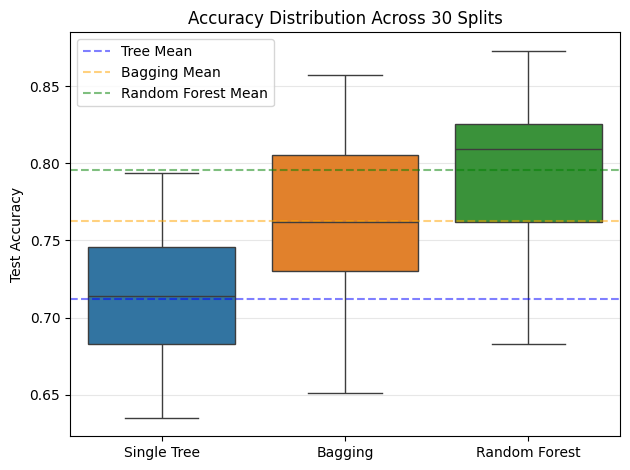

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot comparison
ax = sns.boxplot([tree_scores, bg_scores, rf_scores])
ax.set_xticklabels(['Single Tree', 'Bagging', 'Random Forest'])
plt.ylabel('Test Accuracy')
plt.title('Accuracy Distribution Across 30 Splits')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=tree_scores.mean(), color='blue', linestyle='--', alpha=0.5, label='Tree Mean')
plt.axhline(y=bg_scores.mean(), color='orange', linestyle='--', alpha=0.5, label='Bagging Mean')
plt.axhline(y=rf_scores.mean(), color='green', linestyle='--', alpha=0.5, label='Random Forest Mean')
plt.legend()

plt.tight_layout()

# In-class RF Activity

Build a Random Forest for Wines to predict quality

In [34]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Please enter your code here.

## **Ensemble Methods:** Gradient Boosting Machine (GBM)

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(n_estimators=100,
                                       learning_rate = 0.2,
                                       max_depth = 5,
                                       min_samples_leaf = 3)

# Train the model on the training data
gbc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbc = gbc_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
print(f"Accuracy of Gradient Boosting Classifier: {accuracy_gbc:.4f}")

Accuracy of Gradient Boosting Classifier: 0.8095


### GBM Hyperparameter Tuning
Which hyperparameter leads to the best GBM model. We will perform hyperparameter tuning using `GridSearchCV` to find the optimal parameters.

In [46]:
from sklearn.model_selection import GridSearchCV

# create the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize the Gradient Boosting Classifier (without specific parameters for now, GridSearchCV will handle it)
gbc = GradientBoostingClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid,
                           cv=5, scoring='accuracy')

# Perform Grid Search on the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed. Best parameters and score will be retrieved next.")

GridSearchCV completed. Best parameters and score will be retrieved next.


Let us now see what the best model is.

In [47]:
# retrieve parameters of best model
best_params = grid_search.best_params_

print(best_params)

{'learning_rate': 0.1, 'max_depth': 3}


### Evaluate Best GBM Model


In [49]:
from sklearn.metrics import accuracy_score

# Retrieve the best estimator
best_gbm_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_tuned = best_gbm_model.predict(X_test)

# Calculate the accuracy
accuracy_tuned_gbm = accuracy_score(y_test, y_pred_tuned)

# Print the calculated accuracy
print(f"Accuracy of tuned Gradient Boosting Classifier: {accuracy_tuned_gbm:.4f}")

Accuracy of tuned Gradient Boosting Classifier: 0.8254


## **Ensemble Methods:** XGBoost

In [100]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xg_model = XGBClassifier(
    n_estimators=100,      # Number of trees
    learning_rate=0.1,     # Shrinkage (0.01-0.3)
    max_depth=6,           # Tree depth (3-10)
    subsample=0.8,         # Row sampling
    colsample_bytree=0.8,  # Column sampling
    random_state=42
)

# Train the model
xg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xg = xg_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Evaluate the model
accuracy_xg = accuracy_score(y_test, y_pred_xg)
print(f"Accuracy of XGBoost Classifier: {accuracy_xg:.4f}")

Accuracy of XGBoost Classifier: 0.8413


## **Comparing All Ensemble Models**

In [108]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Run experiment with MULTIPLE random seeds
n_experiments = 30
tree_scores = []
bg_scores = []
rf_scores = []
gbm_scores = []
xg_scores = []

for random_seed in range(n_experiments):
    # Different split each time
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X, y, test_size=0.3, random_state=random_seed, stratify=y
    )

    # Single tree
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train_exp, y_train_exp)
    tree_scores.append(tree.score(X_test_exp, y_test_exp))

    # Bagging
    bg = BaggingClassifier(n_estimators=100,
                           max_samples = 0.5,
                           random_state = 42)
    bg.fit(X_train_exp, y_train_exp)
    bg_scores.append(bg.score(X_test_exp, y_test_exp))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100,
                                max_samples = 0.5,
                                random_state = 42)
    rf.fit(X_train_exp, y_train_exp)
    rf_scores.append(rf.score(X_test_exp, y_test_exp))

    # GBM
    gbm = GradientBoostingClassifier(n_estimators=100,
                                     learning_rate = 0.1,
                                     max_depth = 3,
                                     random_state = 42)
    gbm.fit(X_train_exp, y_train_exp)
    gbm_scores.append(gbm.score(X_test_exp, y_test_exp))

    # XGBoost
    xg = XGBClassifier(n_estimators=100,
                       learning_rate=0.1,
                       max_depth=3,
                       random_state = 42
                       )
    xg.fit(X_train_exp, y_train_exp)
    xg_scores.append(xg.score(X_test_exp, y_test_exp))

# Convert to arrays
tree_scores = np.array(tree_scores)
bg_scores = np.array(bg_scores)
rf_scores = np.array(rf_scores)
gbm_scores = np.array(gbm_scores)
xg_scores = np.array(xg_scores)

# store results in a data frame
results = pd.DataFrame({
    'Model': ['Single Decision Tree', 'Bagging', 'Random Forest', 'GBM', 'XGBoost'],
    'Mean Accuracy': [f"{tree_scores.mean():.3f}", f"{bg_scores.mean():.3f}", f"{rf_scores.mean():.3f}", f"{gbm_scores.mean():.3f}", f"{xg_scores.mean():.3f}"],
    'Std Dev': [f"{tree_scores.std():.3f}", f"{bg_scores.std():.3f}", f"{rf_scores.std():.3f}", f"{gbm_scores.std():.3f}", f"{xg_scores.std():.3f}"],
    'Min': [f"{tree_scores.min():.3f}", f"{bg_scores.min():.3f}", f"{rf_scores.min():.3f}", f"{gbm_scores.min():.3f}", f"{xg_scores.min():.3f}"],
    'Max': [f"{tree_scores.max():.3f}", f"{bg_scores.max():.3f}", f"{rf_scores.max():.3f}", f"{gbm_scores.max():.3f}", f"{xg_scores.max():.3f}"],
    'Range': [f"{tree_scores.max() - tree_scores.min():.3f}",
              f"{bg_scores.max() - bg_scores.min():.3f}",
              f"{rf_scores.max() - rf_scores.min():.3f}",
              f"{gbm_scores.max() - gbm_scores.min():.3f}",
              f"{xg_scores.max() - xg_scores.min():.3f}"]
})

print("\n" + results.to_string(index=False))



               Model Mean Accuracy Std Dev   Min   Max Range
Single Decision Tree         0.712   0.044 0.635 0.794 0.159
             Bagging         0.762   0.049 0.651 0.857 0.206
       Random Forest         0.796   0.044 0.683 0.873 0.190
                 GBM         0.812   0.042 0.730 0.889 0.159
             XGBoost         0.824   0.043 0.730 0.889 0.159


/tmp/ipykernel_1376/1740546525.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single Tree', 'Bagging', 'Random Forest', 'GBM', 'XGBoost'])


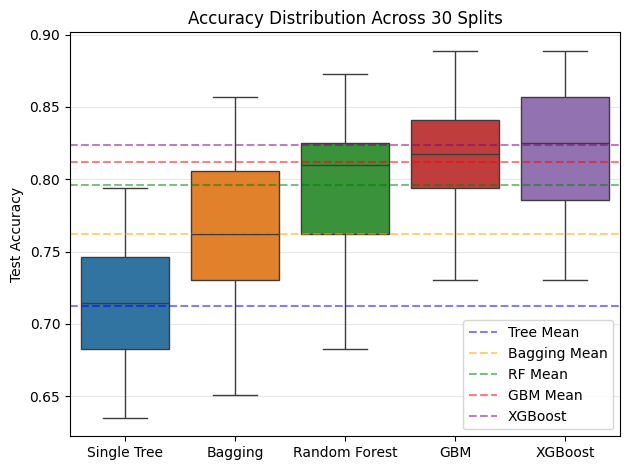

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot comparison
ax = sns.boxplot([tree_scores, bg_scores, rf_scores, gbm_scores, xg_scores])
ax.set_xticklabels(['Single Tree', 'Bagging', 'Random Forest', 'GBM', 'XGBoost'])
plt.ylabel('Test Accuracy')
plt.title('Accuracy Distribution Across 30 Splits')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=tree_scores.mean(), color='blue', linestyle='--', alpha=0.5, label='Tree Mean')
plt.axhline(y=bg_scores.mean(), color='orange', linestyle='--', alpha=0.5, label='Bagging Mean')
plt.axhline(y=rf_scores.mean(), color='green', linestyle='--', alpha=0.5, label='RF Mean')
plt.axhline(y=gbm_scores.mean(), color='red', linestyle='--', alpha=0.5, label='GBM Mean')
plt.axhline(y=xg_scores.mean(), color='purple', linestyle='--', alpha=0.5, label='XGBoost')
plt.legend()

plt.tight_layout()